In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


<h1><font color="whitegreen"> Data Exploration </font> </h1>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Projects/Healthcare-Insurance-Analysis/insurance.csv')
df

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1332,1333,50,male,30.970,3,no,northwest,10600.54830
1333,1334,18,female,31.920,0,no,northeast,2205.98080
1334,1335,18,female,36.850,0,no,southeast,1629.83350
1335,1336,21,female,25.800,0,no,southwest,2007.94500


<h1><font color="whitegreen">1. Initial Exploration </font> </h1>

In [ ]:
df.head()

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges
0,0,19,female,27.900,0,yes,southwest,16884.92400
1,1,18,male,33.770,1,no,southeast,1725.55230
2,2,28,male,33.000,3,no,southeast,4449.46200
3,3,33,male,22.705,0,no,northwest,21984.47061
4,4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1337, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1337 non-null   int64  
 1   age         1337 non-null   int64  
 2   sex         1337 non-null   object 
 3   bmi         1337 non-null   float64
 4   children    1337 non-null   int64  
 5   smoker      1337 non-null   object 
 6   region      1337 non-null   object 
 7   charges     1337 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,Unnamed: 0,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000,1337.000000
mean,668.565445,39.222139,30.663452,1.095737,13279.121487
std,386.528803,14.044333,6.100468,1.205571,12110.359656
min,0.000000,18.000000,15.960000,0.000000,1121.873900
25%,334.000000,27.000000,26.290000,0.000000,4746.344000
50%,669.000000,39.000000,30.400000,1.000000,9386.161300
75%,1003.000000,51.000000,34.700000,2.000000,16657.717450
max,1337.000000,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


<h1><font color="whitegreen">2. Duplicate Records</font> </h1>

In [ ]:
df.duplicated().sum()

np.int64(0)

<h3><font color="redyellow">
Finding: One fully duplicated row was found.
</font> </h3>

In [ ]:
df[df.duplicated()]

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges


In [ ]:
df[df.duplicated(keep=False)]

,Unnamed: 0,age,sex,bmi,children,smoker,region,charges


<h3><font color="redyellow">
Cleaning Decision:<hr>
A duplicate row was detected in the original data. <br>
After confirming it was a perfect match with another row, it was deleted.<br>
Shape after deletion: (1337, 7) instead of (1338, 7).
</font> </h3>

In [ ]:
df = df.drop_duplicates()
# Remove The duplicated entrie
print("The Shape After Removal:",df.shape)

The Shape After Removal: (1337, 8)


<h1><font color="whitegreen">
3. Categorical Columns — Consistency Check
</font> </h1>


In [ ]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


<h3><font color="redyellow">
Finding: All categorical columns are already clean and consistent — no inconsistent casing or spelling variants. No standardization needed.
</font> </h3>


<h1><font color="whitegreen">
4. Numeric Columns — Range & Distribution Check
</font> </h1>



In [ ]:
df[['age', 'bmi', 'children', 'charges']].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


<h3><font color="redyellow">
Finding: All ranges are plausible — age falls within a realistic adult range, bmi and charges are positive with no impossible values, children is a small non-negative integer.
</font> </h3>



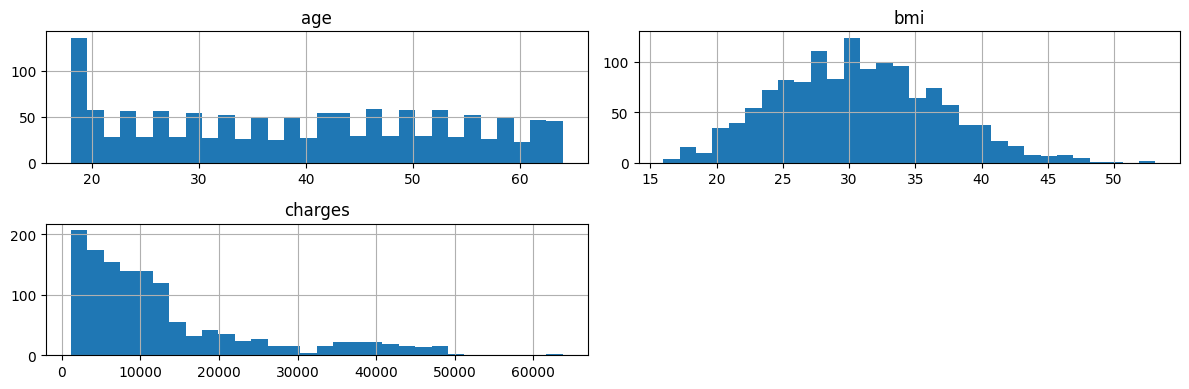

In [ ]:


df[['age', 'bmi', 'charges']].hist(figsize=(12, 4), bins=30)
plt.tight_layout()
plt.show()

<h1><font color="whitegreen">
5. Outlier Check (charges)
</font> </h1>




In [ ]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['charges'] < lower_bound) | (df['charges'] > upper_bound)]
print(f"Number of outliers in 'charges' (IQR method): {len(outliers)}")
print(f"Bounds: lower = {lower_bound:.2f}, upper = {upper_bound:.2f}")

Number of outliers in 'charges' (IQR method): 139
Bounds: lower = -13120.72, upper = 34524.78


<h3><font color="redyellow">
Decision: <br>
These high-charges records are kept in the dataset. <br>
They are not data-entry errors — they most likely correspond to smokers and/or high-BMI patients, which is directly relevant to the business question of what drives medical costs. <br>
This will be explored further in the diagnostic analytics phase.
</font> </h3>

<h1><font color="whitegreen">
6. Save the Cleaned Dataset
</font> </h1>





In [ ]:
df.to_csv('/content/drive/MyDrive/Colab Projects/Healthcare-Insurance-Analysis/data/processed/insurance_clean.csv',
           index=False,
           encoding='utf-8')
print("Saved cleaned dataset to data/processed/insurance_clean.csv")

Saved cleaned dataset to data/processed/insurance_clean.csv
